# Nested Sampling of an Emission Spectrum Using JAXNS 

Last update: September 2026, Hajime Kawahara, for ExoJAX 2.5.0

This guide performs retrieval of an emission spectrum using [nested sampling](https://en.wikipedia.org/wiki/Nested_sampling_algorithm). It follows the same forward-modeling workflow as [Getting Started with Emission Spectroscopy](get_started.html), but uses nested sampling instead of HMC-NUTS for parameter inference.

Both sampler tutorials now read one saved, seeded mock observation and use one shared retrieval model. Prepare the case with the commands in Section 5 before running the observation cell. This update has not rerun the full CO/database retrieval. Earlier forward-model figures are retained from the previous execution; outputs from the changed observation and subsequent retrieval cells have been cleared.


This notebook enables 64-bit mode in JAX. This is useful for numerical stability in retrieval examples, although 32-bit mode is often sufficient and can be faster with lower device-memory use in production workflows.


In [ ]:
from jax import config
config.update("jax_enable_x64", True)

from pathlib import Path
import sys

# Open this notebook inside an ExoJAX source checkout.
repo_root = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "examples" / "compare_samplers.py").is_file()
)
sys.path.insert(0, str(repo_root / "examples"))


The schematic below summarizes the ExoJAX workflow:

1. load databases (`*db`),
2. compute opacity (`opa`),
3. run atmospheric radiative transfer (`art`), and
4. apply spectral operations (`sop`).

In this guide, CO and CIA provide the opacity sources. Their databases, `mdb` and `cdb`, are converted by `opa` into layer opacities. The radiative-transfer object `art` computes the raw spectrum, and `sop` applies rotational, instrumental, and velocity operations.

`mdb`/`cdb` -> `opa` -> `art` -> `sop` -> spectrum

The same spectral model is later embedded in a probabilistic model for retrieval.

![Figure. Structure of ExoJAX](https://secondearths.sakura.ne.jp/exojax/figures/exojax_get_started.png)


## 1. Loading a molecular database using mdb

ExoJAX provides molecular database APIs called `mdb` and atomic database APIs called `adb`. Define the wavenumber grid before loading a database.


In [2]:
from exojax.utils.grids import wavenumber_grid

nu_grid, wav, resolution = wavenumber_grid(
    22920.0, 23000.0, 3500, unit="AA", xsmode="premodit"
)
print("Resolution=", resolution)

xsmode =  premodit
xsmode assumes ESLOG in wavenumber space: xsmode=premodit
Your wavelength grid is in ***  descending  *** order
The wavenumber grid is in ascending order by definition.
Please be careful when you use the wavelength grid.
Resolution= 1004211.9840291934


/home/kawahara/exojax/src/exojax/utils/grids.py:85: UserWarning: Both input wavelength and output wavenumber are in ascending order.
  warnings.warn(


Next, load the molecular database. This example uses carbon monoxide from ExoMol. The path `CO/12C-16O/Li2015` means `molecule / isotopologue / database name`. Database names can be checked on the [ExoMol website](https://www.exomol.com/).


In [3]:
from exojax.database.exomol.api import MdbExomol
mdb = MdbExomol(".database/CO/12C-16O/Li2015", nurange=nu_grid)
molmass = mdb.molmass

/home/kawahara/exojax/src/exojax/utils/molname.py:197: FutureWarning: e2s will be replaced to exact_molname_exomol_to_simple_molname.
  warnings.warn(
/home/kawahara/exojax/src/exojax/utils/molname.py:91: FutureWarning: exojax.utils.molname.exact_molname_exomol_to_simple_molname will be replaced to radis.api.exomolapi.exact_molname_exomol_to_simple_molname.
  warnings.warn(
/home/kawahara/exojax/src/exojax/utils/molname.py:91: FutureWarning: exojax.utils.molname.exact_molname_exomol_to_simple_molname will be replaced to radis.api.exomolapi.exact_molname_exomol_to_simple_molname.
  warnings.warn(


HITRAN exact name= (12C)(16O)
radis engine =  vaex
Molecule:  CO
Isotopologue:  12C-16O
ExoMol database:  None
Local folder:  .database/CO/12C-16O/Li2015
Transition files: 
	 => File 12C-16O__Li2015.trans
Broadener:  H2
Broadening code level: a0


/home/kawahara/anaconda3/lib/python3.10/site-packages/radis/api/exomolapi.py:727: AccuracyWarning: The default broadening parameter (alpha = 0.07 cm^-1 and n = 0.5) are used for J'' > 80 up to J'' = 152
  warnings.warn(


## 2. Computation of the Cross Section using opa

ExoJAX provides several opacity calculator classes, collectively called `opa`. Here we use the memory-efficient `OpaPremodit` calculator. We set the temperature range used by the calculator to 500-1500 K.


In [4]:
from exojax.opacity import OpaPremodit
snap = mdb.to_snapshot()
del mdb
opa = OpaPremodit.from_snapshot(snap, nu_grid, auto_trange=[500.0, 1500.0], dit_grid_resolution=1.0)

/home/kawahara/exojax/src/exojax/opacity/premodit/core.py:28: UserWarning: dit_grid_resolution is not None. Ignoring broadening_parameter_resolution.
  warnings.warn(


default elower grid trange (degt) file version: 2
Robust range: 485.7803992045456 - 1514.171191195336 K
max value of  ngamma_ref_grid : 9.450919102366303
min value of  ngamma_ref_grid : 7.881095721823979
ngamma_ref_grid grid : [7.88109541 9.4509201 ]
max value of  n_Texp_grid : 0.658
min value of  n_Texp_grid : 0.5
n_Texp_grid grid : [0.49999997 0.65800005]


uniqidx: 0it [00:00, ?it/s]

Premodit: Twt= 1108.7151960064205 K Tref= 570.4914318566549 K
Making LSD: 100%


Compute cross sections at 500 K and 1500 K for a pressure of 1.0 bar using `opa.xsvector`.


In [5]:
P = 1.0  # bar
T_1 = 500.0  # K
xsv_1 = opa.xsvector(T_1, P)  # cm2

T_2 = 1500.0  # K
xsv_2 = opa.xsvector(T_2, P)  # cm2

Plotting the cross sections shows that different lines dominate at different temperatures.


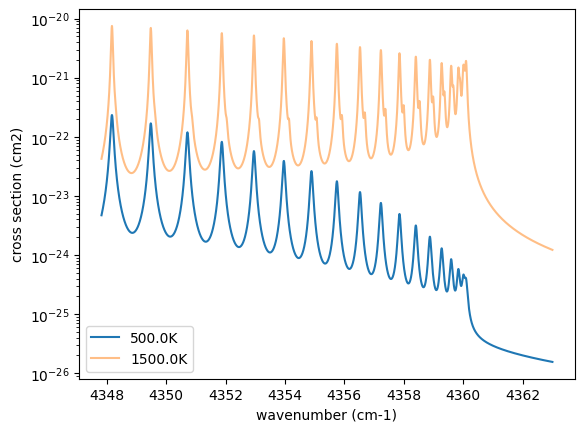

In [6]:
import matplotlib.pyplot as plt

plt.plot(nu_grid, xsv_1, label=str(T_1) + "K")  # cm2
plt.plot(nu_grid, xsv_2, alpha=0.5, label=str(T_2) + "K")  # cm2
plt.yscale("log")
plt.legend()
plt.xlabel("wavenumber (cm-1)")
plt.ylabel("cross section (cm2)")
plt.show()

## 3. Atmospheric Radiative Transfer

ExoJAX solves radiative transfer and returns the emission spectrum through an `art` object. `ArtEmisPure` means atmospheric radiative transfer for emission with pure absorption, without scattering. Here we use 100 atmospheric layers whose representative pressures range from 1.0e-5 bar at the top to 10 bar at the bottom.

Since v1.5, ExoJAX supports both the flux-based two-stream solver (`fbased2st`) and the intensity-based n-stream solver (`ibased`). This example uses `rtsolver="ibased"`.


In [7]:
from exojax.rt import ArtEmisPure

art = ArtEmisPure(
    nu_grid=nu_grid,
    pressure_btm=1.0e1,
    pressure_top=1.0e-5,
    nlayer=100,
    rtsolver="ibased",
    nstream=8,
)

rtsolver:  ibased
Intensity-based n-stream solver, isothermal layer (e.g. NEMESIS, pRT like)


Assume a power-law temperature profile between 500 K and 1500 K:

$T = T_0 P^{\alpha}$,

where $T_0 = 1200$ K and $\alpha = 0.1$.


In [8]:
art.change_temperature_range(500.0, 1500.0)
Tarr = art.powerlaw_temperature(1200.0, 0.1)

Also, the mass mixing ratio of CO (MMR) should be defined.

In [9]:
mmr_profile = art.constant_mmr_profile(0.01)

Surface gravity is another key atmospheric parameter. It depends on planetary radius and mass. Here we assume 1 Jupiter radius and 10 Jupiter masses.


In [10]:
from exojax.utils.astrofunc import gravity_jupiter

gravity = gravity_jupiter(1.0, 10.0)

In addition to CO absorption, include [collision-induced absorption](https://en.wikipedia.org/wiki/Collision-induced_absorption_and_emission) (CIA) as continuum opacity. CIA data are handled with a `cdb` object.


In [11]:
from exojax.database.contdb  import CdbCIA
from exojax.opacity import OpaCIA

cdb = CdbCIA(".database/H2-H2_2011.cia", nurange=nu_grid)
opacia = OpaCIA(cdb, nu_grid=nu_grid)

H2-H2


Before running radiative transfer, compute layer quantities: `xsmatrix` for CO and `logacia_matrix` for CIA. Strictly speaking, CIA uses an absorption coefficient rather than a cross section because its intensity is proportional to density squared. See [CIA opacity](CIA_opacity.html) for details.


In [12]:
xsmatrix = opa.xsmatrix(Tarr, art.pressure)
logacia_matrix = opacia.logacia_matrix(Tarr)

Convert the layer quantities into optical depth.


In [13]:
dtau_CO = art.opacity_profile_xs(xsmatrix, mmr_profile, molmass, gravity)
vmrH2 = 0.855  # VMR of H2
mmw = 2.33  # mean molecular weight of the atmosphere
dtaucia = art.opacity_profile_cia(logacia_matrix, Tarr, vmrH2, vmrH2, mmw, gravity)

Add the molecular and continuum optical depths.


In [14]:
dtau = dtau_CO + dtaucia

Run the radiative-transfer solver to generate the emission spectrum. The dense CO features near 4360 cm-1, or about 22940 AA, form a band head. For the line-physics background, see [Quantum states of Carbon Monoxide and Fortrat Diagram](Fortrat.html).


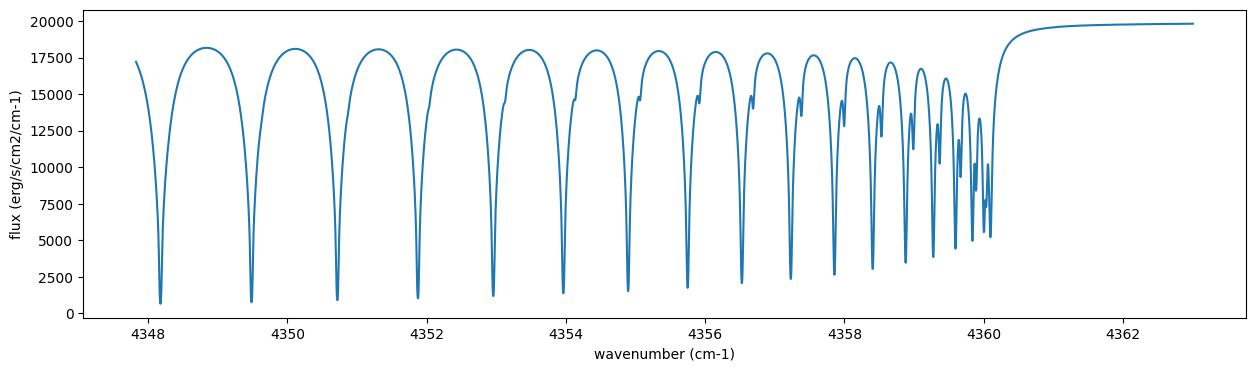

In [15]:
F = art.run(dtau, Tarr)

fig = plt.figure(figsize=(15, 4))
plt.plot(nu_grid, F)
plt.xlabel("wavenumber (cm-1)")
plt.ylabel("flux (erg/s/cm2/cm-1)")
plt.show()

The contribution function is useful for checking whether the dominant emitting layers are inside the modeled pressure range. If not, adjust `pressure_top` or `pressure_btm` in `ArtEmisPure`.


In [16]:
from exojax.plot.atmplot import plotcf

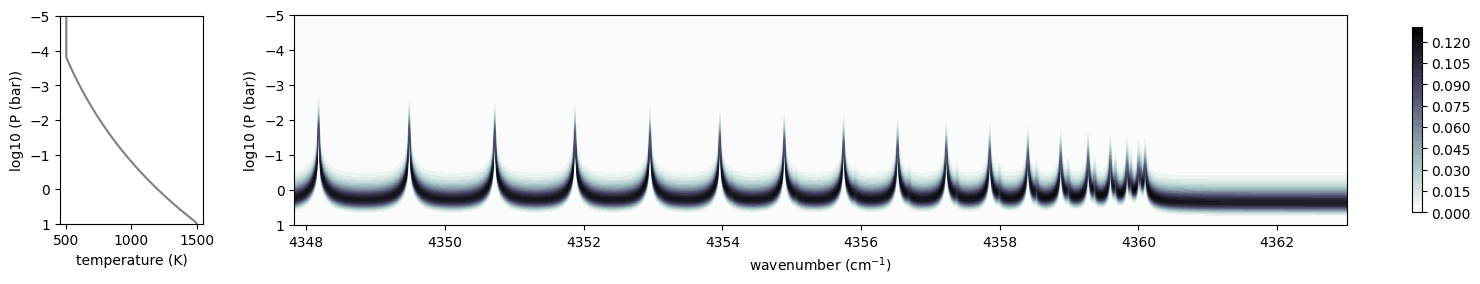

In [17]:
cf = plotcf(nu_grid, dtau, Tarr, art.pressure, art.dParr)

## 4. Spectral Operators

Spectral operators apply effects such as rotational broadening, instrumental broadening, Doppler velocity shifts, and sampling onto an observational grid.


The spectrum produced by radiative transfer is the raw spectrum. ExoJAX applies post-processing effects with spectral operators (`sop`). First, apply rotational broadening from planetary spin.


In [18]:
from exojax.postproc.specop import SopRotation

sop_rot = SopRotation(nu_grid, vsini_max=100.0)

vsini = 10.0
u1 = 0.0
u2 = 0.0
Frot = sop_rot.rigid_rotation(F, vsini, u1, u2)

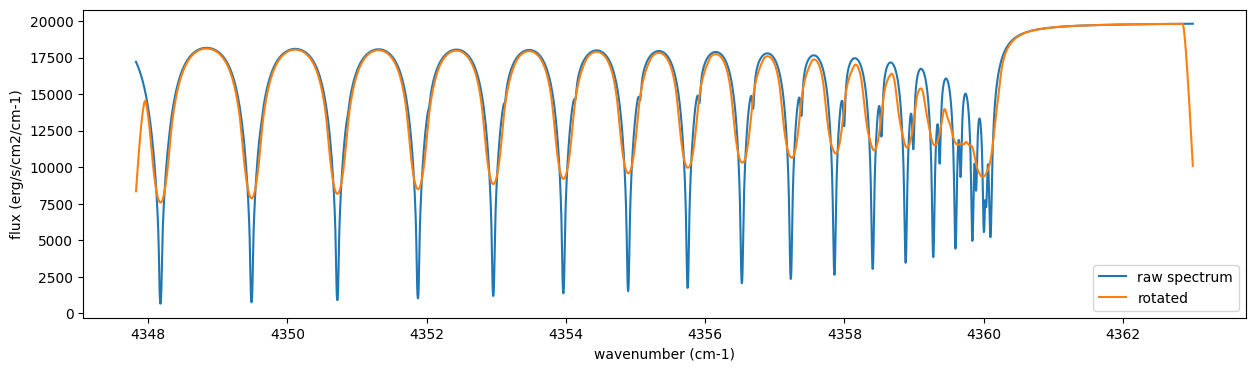

In [19]:
fig = plt.figure(figsize=(15, 4))
plt.plot(nu_grid, F, label="raw spectrum")
plt.plot(nu_grid, Frot, label="rotated")
plt.xlabel("wavenumber (cm-1)")
plt.ylabel("flux (erg/s/cm2/cm-1)")
plt.legend()
plt.show()

Next, apply the instrumental profile and relative radial-velocity shift. Evaluating the model on the observed wavenumber grid is called `sampling` in ExoJAX. The physical operations remain visible below, while the observation itself is loaded from the case prepared once for both samplers.


In [ ]:
from exojax.postproc.specop import SopInstProfile
from exojax.utils.instfunc import resolution_to_gaussian_std
from compare_samplers import load_context

sop_inst = SopInstProfile(nu_grid, vrmax=1000.0)
RV = 40.0  # km/s
resolution_inst = 70000.0
beta_inst = resolution_to_gaussian_std(resolution_inst)
Finst = sop_inst.ipgauss(Frot, beta_inst)

# Both sampler tutorials read the observation prepared once by the CLI.
case_dir = repo_root / "output" / "co_sampler_comparison"
case_metadata, case_data, model_context = load_context(case_dir)
nu_obs = case_data["nu_obs"]
Fobs = case_data["observed_flux"]
noise = float(case_data["noise_sigma"])
print("Shared saved case:", case_dir)


In [ ]:
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(211)
plt.plot(nu_grid, Frot, label="rotated")
plt.plot(nu_grid, Finst, label="rotated+IP")
plt.ylabel("flux (erg/s/cm2/cm-1)")
plt.legend()
ax = fig.add_subplot(212)
plt.errorbar(nu_obs, Fobs, noise, fmt=".", label="rotated + RV + IP (sampling)", color="gray",alpha=0.5)
plt.xlabel("wavenumber (cm-1)")
plt.legend()
plt.show()

## 5. Retrieval of an Emission Spectrum

Next, retrieve atmospheric parameters from the saved mock spectrum. The explanatory steps above show how opacity, radiative transfer, and spectral operations fit together. The shared forward factory below applies those same steps using the saved case, so both sampler entry points use identical physical inputs.


In [ ]:
from _co_retrieval import make_forward, make_numpyro_model

# The saved case supplies the same opacities and operators for both samplers.
fspec = make_forward(model_context)


Check that `fspec` generates spectra for different parameter sets.


In [ ]:
fig = plt.figure(figsize=(12, 3))

plt.plot(nu_obs, fspec(1200.0, 0.09, 0.01, gravity_jupiter(1.0, 1.0), 40.0, 10.0),label="model")
plt.plot(nu_obs, fspec(1100.0, 0.12, 0.01, gravity_jupiter(1.0, 10.0), 20.0, 5.0),label="model")

Both sampler entry points use the same forward model, prior specifications, and normalized likelihood. The six physical priors are `logg ~ Uniform(4, 5)`, `RV ~ Uniform(35, 45)` km/s, `MMR ~ Uniform(0, 0.015)`, `T0 ~ Uniform(1000, 1500)` K, `alpha ~ Uniform(0.05, 0.2)`, and `vsini ~ Uniform(5, 15)` km/s. Here `logg` is the base-10 logarithm of gravity in cm/s2; MMR and `alpha` are dimensionless.

The noise standard deviation has the original `sigmain ~ Exponential(1e-3)` prior, whose mean is 1000 in the flux units erg/s/cm2/cm-1. The saved mock observation uses a standard deviation of 500 in these same units. The normalized likelihood is a product of independent Gaussian densities, with mean `fspec` and standard deviation `sigmain`; its normalization is included when calculating evidence.

NUTS transforms these physical parameters to unconstrained coordinates. JAXNS uses a unit-cube prior transform. Offline tests check that their physical-space likelihoods and normalized priors agree, including the transformations' Jacobians.


In [ ]:
from jax import random
import numpy as np
from compare_samplers import load_run


In [ ]:
model_prob = make_numpyro_model(fspec)


### Run the sampler comparison from the source checkout

Prepare one observation with seed 0, then run each sampler in a separate process. Run these commands from the repository root; adjust the database paths if needed. Preparation preserves this tutorial's CO atmosphere, spectral grid, and priors. Both tutorials load the resulting `output/co_sampler_comparison` case.

```bash
python examples/compare_samplers.py prepare --output-dir output/co_sampler_comparison --seed 0 --mdb-path .database/CO/12C-16O/Li2015 --cia-path .database/H2-H2_2011.cia
python examples/compare_samplers.py run --output-dir output/co_sampler_comparison --method nuts --run-id repeat-0 --seed 0
python examples/compare_samplers.py run --output-dir output/co_sampler_comparison --method jaxns --run-id repeat-0 --seed 0
python examples/compare_samplers.py summarize --output-dir output/co_sampler_comparison --run-id repeat-0
```

Use a new run ID and seed for independent repetitions. Keep the saved case unchanged. Reports link the observation and model hashes to the settings and sampler-specific diagnostics; a short smoke run does not demonstrate convergence. NUTS chain diagnostics and JAXNS weighted samples, evidence uncertainty, and stopping conditions measure different properties. A NUTS runtime does not measure evidence performance, and the number of equal-weight draws resampled from nested output is not its weighted ESS.

The numerical comparison lives in [`examples/compare_samplers.py`](https://github.com/HajimeKawahara/exojax/blob/develop/examples/compare_samplers.py). See the [NUTS tutorial](get_started.html), [nested-sampling tutorial](get_started_ns.html), and the separate [SVI tutorial](get_started_svi.html). SVI and the Gaussian-process extension are outside this comparison.

### Read a completed nested-sampling run

JAXNS is an optional dependency used by the CLI adapter. Load its saved weighted result after the run finishes; the report preserves the raw weights, evidence uncertainty, and termination status. Inspect those diagnostics before interpreting posterior plots.

The optional adapter targets JAXNS 2.6.9. Its small CPU check used JAX/JAXlib 0.6.2, NumPyro 0.19.0, and `tfp-nightly` 0.26.0.dev20260907. To reproduce that dependency combination, install it in a separate virtual environment with ExoJAX available:

```bash
python -m pip install 'jaxns==2.6.9' 'jax[cpu]==0.6.2' 'tfp-nightly==0.26.0.dev20260907' 'numpyro==0.19.0' 'numpy<2.5'
```

This dependency check and the small CPU smoke run do not establish convergence or performance for the full CO retrieval.


In [ ]:
nested_report, nested_arrays = load_run(case_dir, "jaxns", "repeat-0")
print(nested_report["nested"])


For this predictive illustration only, resample the weighted posterior into 1000 equal-weight draws. This count is a plotting choice, not a nested-sampling ESS or additional independent information. The saved result retains the original weights.


In [ ]:
from numpyro.diagnostics import hpdi
from numpyro.infer import Predictive
import jax.numpy as jnp

In [ ]:
weights = nested_arrays["weights"]
indices = np.random.default_rng(3).choice(len(weights), size=1000, p=weights)
posterior_sample = {
    name: jnp.asarray(nested_arrays["samples__" + name][indices])
    for name in case_metadata["priors"]
}
pred = Predictive(model_prob, posterior_sample, return_sites=["spectrum"])
predictions = pred(random.PRNGKey(0), spectrum=None)
median_mu1 = jnp.median(predictions["spectrum"], axis=0)
hpdi_mu1 = hpdi(predictions["spectrum"], 0.9)


In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(15, 4.5))
ax.plot(nu_obs, median_mu1, color='C1')
ax.fill_between(nu_obs,
                hpdi_mu1[0],
                hpdi_mu1[1],
                alpha=0.3,
                interpolate=True,
                color='C1',
                label='90% area')
ax.errorbar(nu_obs, Fobs, noise, fmt=".", label="mock spectrum", color="black",alpha=0.5)
plt.xlabel('wavenumber (cm-1)', fontsize=16)
plt.legend(fontsize=14)
plt.tick_params(labelsize=14)
plt.show()

After running the saved comparison, inspect the predictive intervals against the common mock observation. The corner plot below uses the same illustrative resampled draws.


In [ ]:
import arviz
pararr = ['T0', 'alpha', 'logg', 'MMR', 'vsini', 'RV']
arviz.plot_pair(posterior_sample,
                kind='kde',
                divergences=False,
                marginals=True)
plt.show()

This completes the nested-sampling getting-started workflow.
